### Import packages

In [88]:
library(readxl)
library(ggfortify)
library(edgeR)
library(ggpubr)
library(ggrepel)
library(randomForest)
library(ggplotify)
library(RColorBrewer)
library(pROC)
library(data.table)


### Read tables resulting from merging_datasets

In [89]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')

In [90]:
m_became = scaled_df[meta[rownames(scaled_df),]$cohort=='BECAME',]
meta_became = meta[rownames(m_became),]
m_became_patients = m_became[rownames(meta_became[which(meta_became$group!='CONTROL'),]),]


m_miracle = scaled_df[meta[rownames(scaled_df),]$cohort=='MIRACLE',]
meta_miracle = meta[rownames(m_miracle),]
m_miracle_patients = m_miracle[rownames(meta_miracle[which(meta_miracle$group!='CONTROL'),]),]


In [91]:
m_became_patients=data.frame(m_became_patients)
m_became_patients$group = meta_became[rownames(m_became_patients),'cluster']
for(i in 1:(ncol(m_became_patients)-1)){
    m_became_patients[,i]=as.numeric(m_became_patients[,i])
}
m_became_patients$group = factor(m_became_patients$group)

### Train random forest to classify the became clusters in the became cohort with the first 70% of samples

In [92]:
set.seed(456)

m_became_patients$group = as.factor(gsub('B','',m_became_patients$group))
m_became_patients$group = factor(m_became_patients$group==1)
# Define your formula for classificatio7
formula <- group~.
keep = c(colnames(m_became_patients)[1:161],'group')
# Train the Random Forest classifier
rf_model_allClusters <- randomForest(formula, 
                         data = m_became_patients[1:round(nrow(m_became_patients)*.7),keep], 
                         ntree = 1000)



In [93]:
predictions_became <- predict(rf_model_allClusters, m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),], type = "response")
accuracy_became <- mean(predictions_became == m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),'group'])
cat("Accuracy:", accuracy_became, "\n")

predictions_miracle <- predict(rf_model_allClusters, m_miracle_patients, type = "response")

Accuracy: 0.9375 


### Generate Confusion Matrices

In [94]:
meta$is_B1 = factor(meta$cluster=='B1')

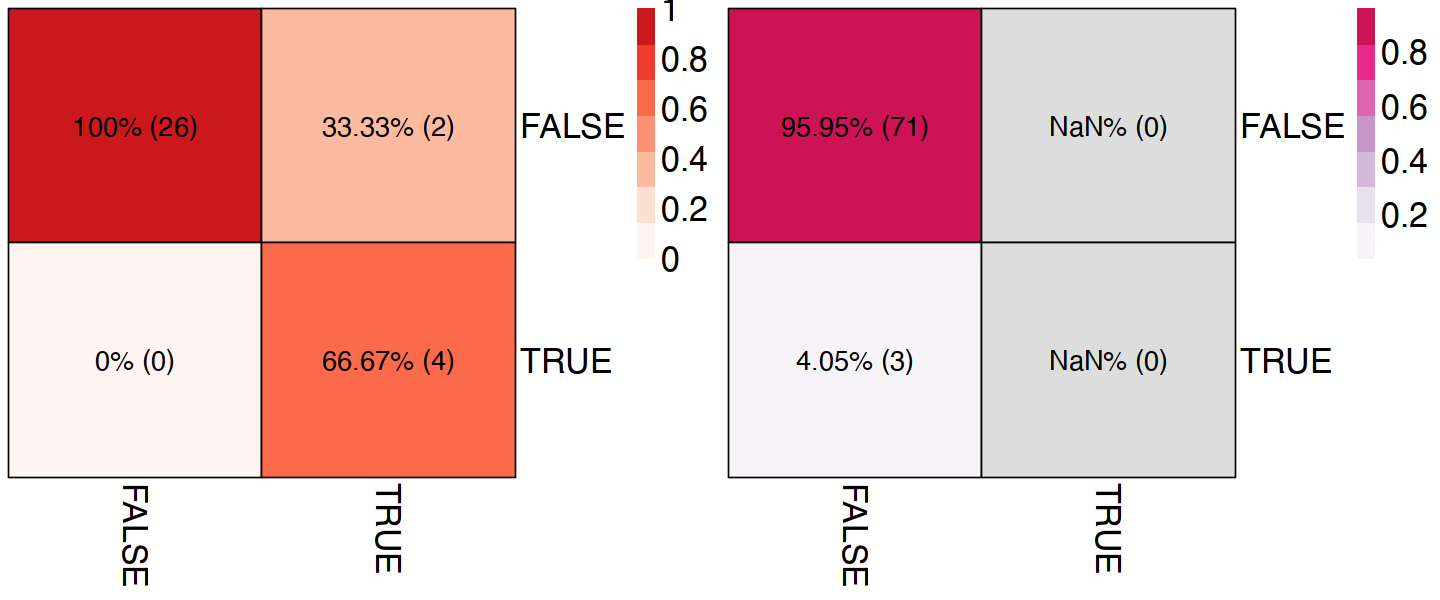

In [95]:
prettify_matrix<-function(t){
    t2 = t
    for(i in 1:ncol(t2)){t2[,i] = t2[,i]/sum(t2[,i])}
    result_matrix <- matrix(nrow = 2, ncol = 2)

    # Loop through the matrices and concatenate corresponding values
    for (i in 1:2) {
      for (j in 1:2) {
        result_matrix[i, j] <- paste0(round(t2[i, j]*100,digits=2), "% (",t[i, j],")", sep = "")
      }
    }
    return(result_matrix) 
}

norm_matrix<-function(t){
    for(i in 1:ncol(t)){t[,i]=t[,i]/sum(t[,i])}   
    return(t)
}

test_became = m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),]
t1 = table(predictions_became,meta[rownames(test_became),'is_B1'])
t2 = table(predictions_miracle[rownames(m_miracle_patients)],meta[rownames(m_miracle_patients),'is_B1'])

ph1 = as.ggplot(pheatmap::pheatmap(norm_matrix(t1),border_col='black',treeheight_col=0,treeheight_row=0,border_width = 10,number_color='black',col=brewer.pal(9,'Reds')[-c(8:11)],display_numbers=prettify_matrix(t1),fontsize=20,cluster_row=F,cluster_col=F,silent=T))
ph2 = as.ggplot(pheatmap::pheatmap(norm_matrix(t2),border_col='black',treeheight_col=0,treeheight_row=0,border_width = 10,number_color='black',col=brewer.pal(9,'PuRd')[-c(8:11)],display_numbers=prettify_matrix(t2),fontsize=20,cluster_row=F,cluster_col=F,silent=T))

options(repr.plot.width = 12, repr.plot.height = 5)
cowplot::plot_grid(ph1,ph2,ncol=2)

### Identify feature importance 

In [96]:
became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=1))
miracle = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=1))


In [97]:
var_importance <- data.frame(importance(rf_model_allClusters))
var_importance$lipid_id_became = became[gsub('X','',rownames(var_importance)),'Lipid.ID']
var_importance$lipid_id_miracle = miracle[gsub('X','',rownames(var_importance)),'Lipid.ID']
var_importance$lipid_class = miracle[gsub('X','',rownames(var_importance)),'Lipid.suclasses']
var_importance$modified_became_id <- with(var_importance, ifelse(duplicated(lipid_id_became) | duplicated(lipid_id_became, fromLast = TRUE), 
                                     paste(lipid_id_became, rowid(lipid_id_became, prefix = "_"), sep = "_"),
                                     lipid_id_became))
var_importance = var_importance[order(-var_importance$MeanDecreaseGini),]

Warning message in xtfrm.data.frame(x):
“cannot xtfrm data frames”


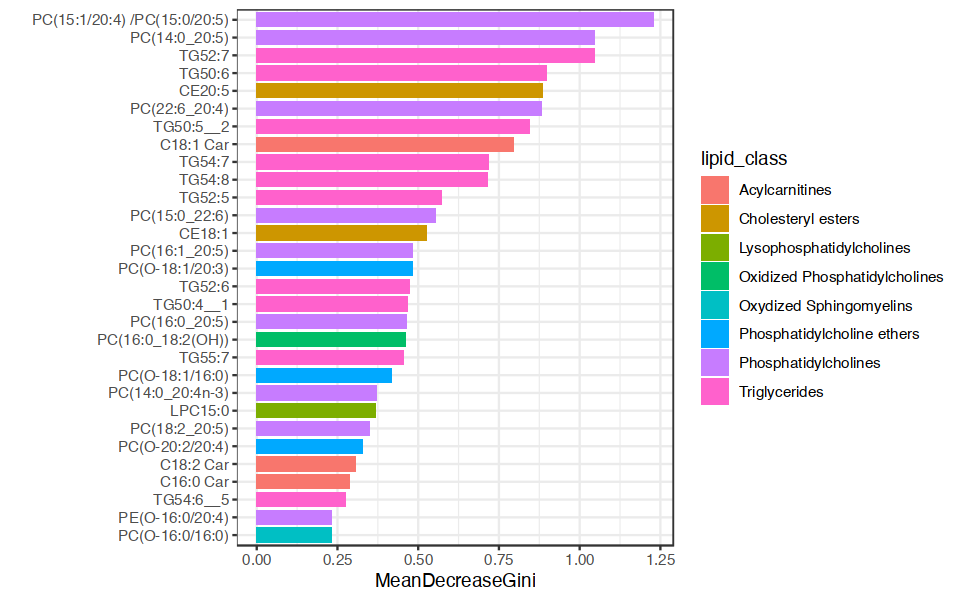

In [98]:
options(repr.plot.width = 8, repr.plot.height = 5)

var_importance$modified_became_id = factor(var_importance$modified_became_id,unique(var_importance[order(var_importance),'modified_became_id']))
ggplot(head(var_importance[order(-var_importance$MeanDecreaseGini),],30),aes(modified_became_id,MeanDecreaseGini))+
    geom_col(aes(fill=lipid_class),width=.8)+
    coord_flip()+
    theme_bw()+
    xlab('')

### Cumulative feature corruption's effect on accuracy of the model 

In [99]:
## Feature Corruption

experiment<-function(strategy='mean'){
    res = data.frame()
    
    corrupted_ordered = m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),]
    corrupted_random = m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),]
    corrupted_ordered_rev = m_became_patients[round(nrow(m_became_patients)*.7):nrow(m_became_patients),]
    random_features = sample(rownames(var_importance))
    
    ## Putting the mean 
    
    for(i in 1:161){
        if(strategy=='mean'){
            corrupted_ordered[,rownames(var_importance)[i]] = rep(mean(corrupted_ordered[,rownames(var_importance)[i]]),nrow(corrupted_ordered))
            corrupted_ordered_rev[,rownames(var_importance)[nrow(var_importance)+1-i]] = rep(mean(corrupted_ordered_rev[,rownames(var_importance)[nrow(var_importance)+1-i]]),nrow(corrupted_ordered))
            corrupted_random[,random_features[i]] = rep(mean(corrupted_random[,random_features[i]]),nrow(corrupted_ordered))
        }else{
            corrupted_ordered[,rownames(var_importance)[i]] = sample(corrupted_ordered[,rownames(var_importance)[i]])
            corrupted_ordered_rev[,rownames(var_importance)[nrow(var_importance)+1-i]] = sample(corrupted_ordered_rev[,rownames(var_importance)[nrow(var_importance)+1-i]])
            corrupted_random[,random_features[i]] = sample(corrupted_random[,random_features[i]])
        }
        
        predictions_ordered <- predict(rf_model_allClusters, corrupted_ordered, type = "response")
        predictions_ordered_rev <- predict(rf_model_allClusters, corrupted_ordered_rev, type = "response")
        predictions_random <- predict(rf_model_allClusters, corrupted_random, type = "response")
    
        accuracy_ordered <- mean(predictions_ordered == corrupted_ordered$group)
        accuracy_ordered_rev <- mean(predictions_ordered_rev == corrupted_ordered_rev$group)
        accuracy_random <- mean(predictions_random == corrupted_random$group)
        
        res=rbind(res,c(accuracy_ordered,i,'ordered_best',strategy),c(accuracy_ordered_rev,i,'ordered_worst',strategy),c(accuracy_random,i,'random',strategy))
    }
    colnames(res) = c('accuracy','nfeatures','group','strategy')
    return(res)
}

res = rbind(experiment(strategy='mean'),
            experiment(strategy='permute'))


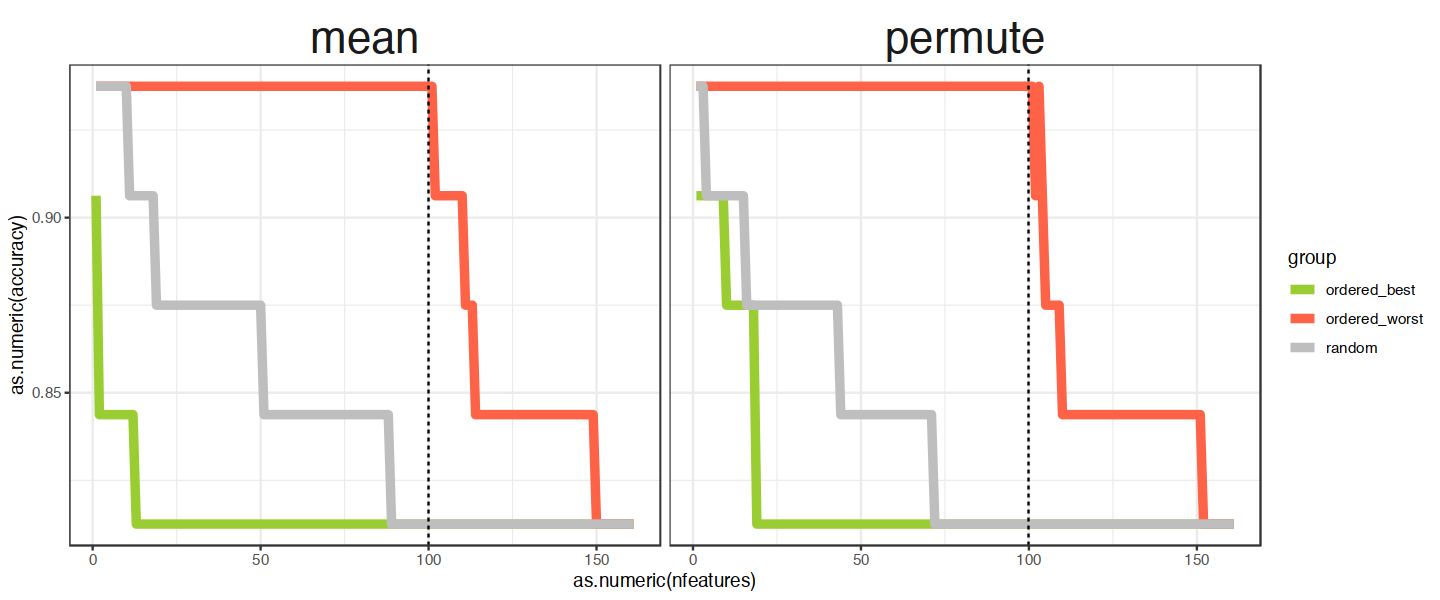

In [108]:
options(repr.plot.width = 12, repr.plot.height = 5)

ggplot(res,aes(as.numeric(nfeatures),as.numeric(accuracy)))+
    geom_line(aes(col=group),size=2)+
    theme_bw()+
    facet_wrap(~strategy)+
    geom_vline(xintercept=100,linetype='dashed')+
    scale_color_manual(values=c('olivedrab3','tomato','grey'))+
    theme(strip.background=element_blank(),strip.text=element_text(size=26))

In [101]:
write.table(var_importance,'../data/var_importance.b1.csv',quote=F,sep=',')

In [102]:
predictions <- predict(rf_model_allClusters, scaled_df, type = "response")

In [103]:
meta$preds = paste0('C',predictions[rownames(meta)])
meta$preds = gsub('CTRUE','B1',meta$preds)
meta$preds = gsub('CFALSE','not-B1',meta$preds)

In [104]:
write.table(meta,'../data/merged_dataset_meta.csv',sep=',',quote=F)

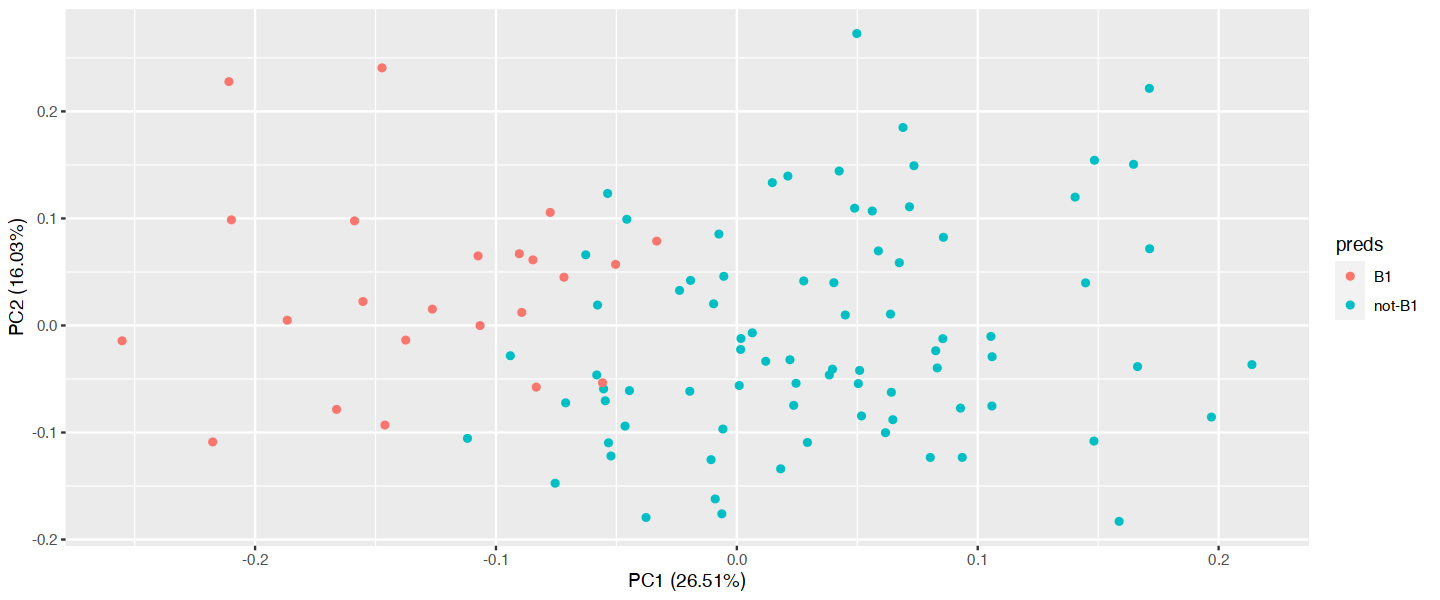

In [105]:
autoplot(prcomp(m_became_patients[,rownames(head(var_importance,100))]),data=meta[rownames(m_became_patients),],col='preds')